# Tesla Deliveries Analysis and Forecasting (2015–2025)

This notebook performs:
- Data Loading and Inspection
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Linear Regression Modeling
- Cross Validation
- Random Forest Optimization
- Stationarity Testing
- Forecast Comparison

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    KFold,
    cross_val_score,
    GridSearchCV
)

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

## Step 1: Load Dataset and Inspect Structure

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

print("\nDescribe:")
display(df.describe())

Shape:
(2640, 12)

Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Typ

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Step 2: Missing Values and Duplicate Check

In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows:
0


## Step 3: Exploratory Data Analysis

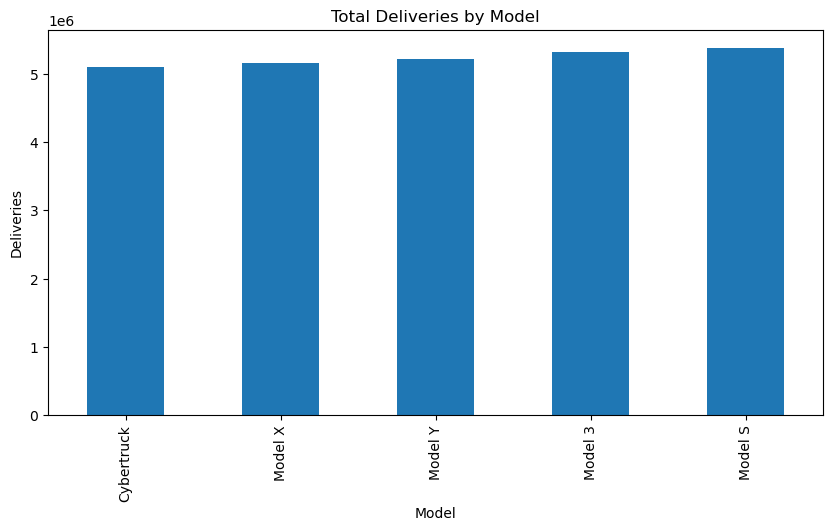

In [4]:
plt.figure(figsize=(10,5))
df.groupby("Model")["Estimated_Deliveries"].sum().sort_values().plot(kind="bar")
plt.title("Total Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Deliveries")
plt.show()

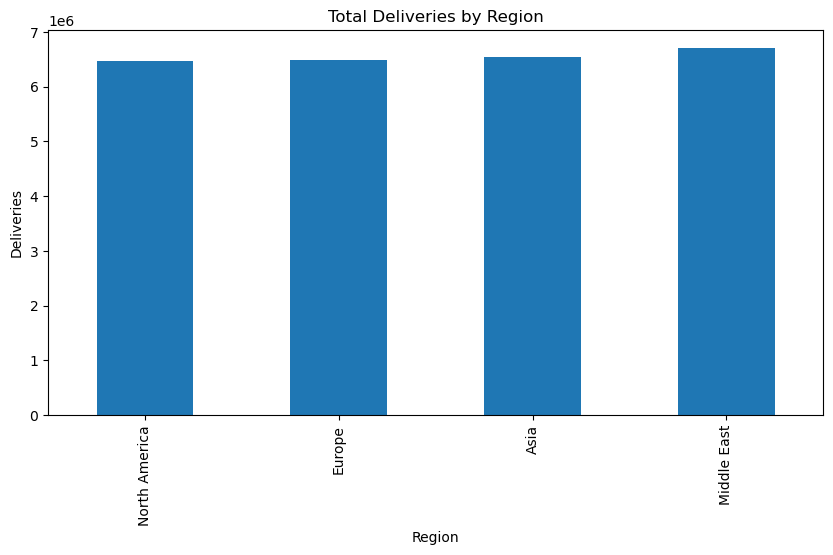

In [5]:
plt.figure(figsize=(10,5))
df.groupby("Region")["Estimated_Deliveries"].sum().sort_values().plot(kind="bar")
plt.title("Total Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Deliveries")
plt.show()

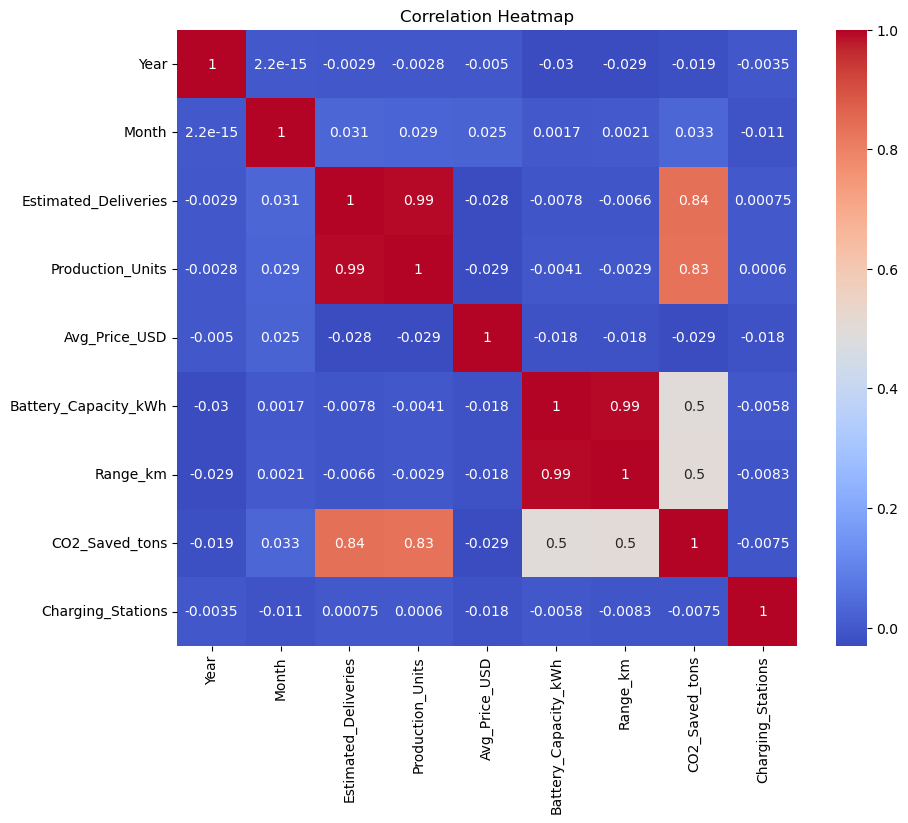

In [6]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

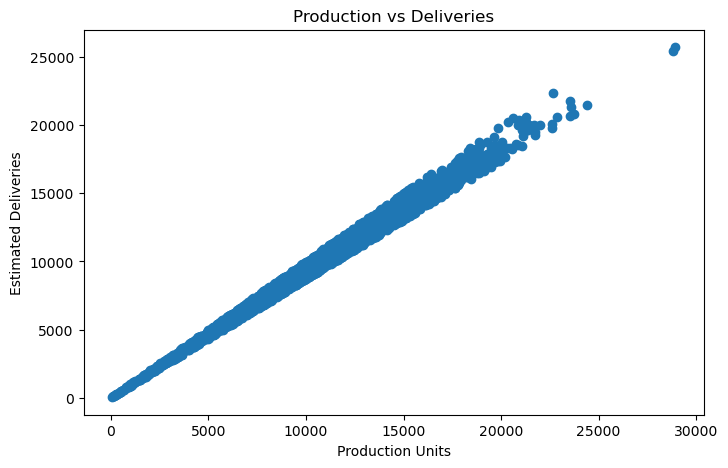

In [7]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Production_Units"],
    df["Estimated_Deliveries"]
)

plt.title("Production vs Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.show()

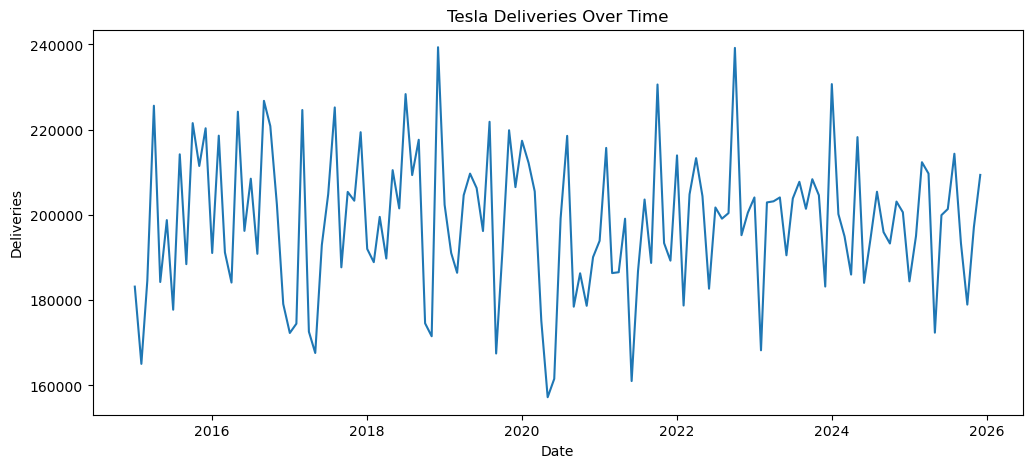

In [8]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

trend = df.groupby("Date")["Estimated_Deliveries"].sum()

plt.figure(figsize=(12,5))
plt.plot(trend.index, trend.values)

plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.show()

## Step 4: Encoding and Feature Engineering

In [9]:
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df["Region"] = le_region.fit_transform(df["Region"])
df["Model"] = le_model.fit_transform(df["Model"])
df["Source_Type"] = le_source.fit_transform(df["Source_Type"])

df = df.sort_values("Date")

df["Deliveries_Lag1"] = (
    df["Estimated_Deliveries"].shift(1)
)

df["Deliveries_Lag1"].fillna(
    df["Deliveries_Lag1"].mean(),
    inplace=True
)

df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
    .rolling(3)
    .mean()
)

df["Rolling_Mean_3"].fillna(
    df["Rolling_Mean_3"].mean(),
    inplace=True
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Deliveries_Lag1,Rolling_Mean_3
872,2015,1,0,4,12446,13885,55183.13,60,340,634.75,2,4390,2015-01-01,9922.428192,9921.338261
2354,2015,1,2,1,11446,12752,89289.40,100,588,1009.54,0,8925,2015-01-01,12446.000000,9921.338261
2312,2015,1,2,0,8803,9344,102888.58,60,336,443.67,1,3923,2015-01-01,11446.000000,10898.333333
2293,2015,1,3,0,6367,6802,104962.32,82,459,438.37,0,9170,2015-01-01,8803.000000,8872.000000
2215,2015,1,0,1,8795,9165,87988.73,82,456,601.58,2,12626,2015-01-01,6367.000000,7988.333333


## Step 5: Linear Regression Using Chronological Split

In [10]:
X = df.drop(
    ["Estimated_Deliveries", "Date"],
    axis=1
)

y = df["Estimated_Deliveries"]

split = int(len(df)*0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [11]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae = mean_absolute_error(y_test, pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, pred_lr))
r2 = r2_score(y_test, pred_lr)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 323.16184943050513
RMSE: 392.2207507853485
R²  : 0.988429413421087


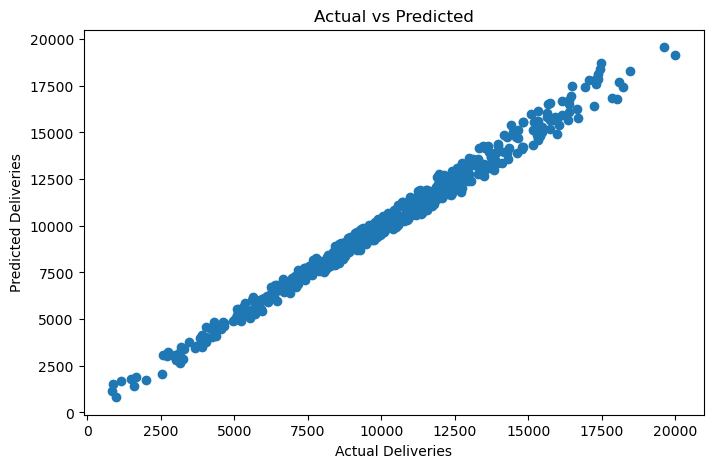

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, pred_lr)

plt.title("Actual vs Predicted")
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")

plt.show()

## Step 6: 5-Fold Cross Validation

In [13]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    lr,
    X,
    y,
    cv=kf,
    scoring="r2"
)

for i, score in enumerate(scores, 1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean R²:", scores.mean())

Fold 1: 0.9904
Fold 2: 0.9897
Fold 3: 0.9906
Fold 4: 0.9909
Fold 5: 0.9898

Mean R²: 0.9902549458758904


## Step 7: Random Forest Hyperparameter Tuning

In [14]:
param_grid = {
    "n_estimators":[50,100],
    "max_depth":[5,10,None]
}

rf = RandomForestRegressor(
    random_state=42
)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train,y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'n_estimators': 100}


In [15]:
best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_test)

print(
    "MAE:",
    mean_absolute_error(y_test,rf_pred)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test,rf_pred))
)

print(
    "R²:",
    r2_score(y_test,rf_pred)
)

MAE: 329.8014962121212
RMSE: 411.46793956511624
R²: 0.9872659589152247


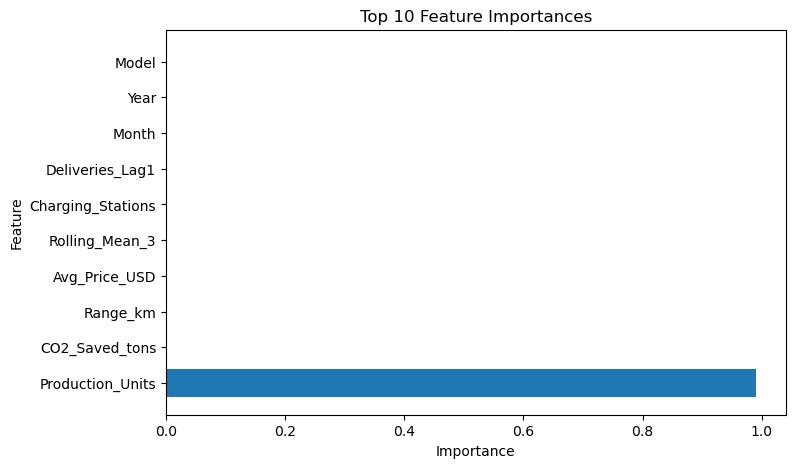

In [16]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Step 8: Stationarity Test (ADF)

In [17]:
adf = adfuller(df["Estimated_Deliveries"])

print("ADF Statistic:", adf[0])
print("p-value:", adf[1])

ADF Statistic: -28.176204468357874
p-value: 0.0


### ADF Interpretation

If p-value < 0.05:
- Reject null hypothesis.
- Series is stationary.

If p-value >= 0.05:
- Fail to reject null hypothesis.
- Series is non-stationary.

## Step 9: Forecast Comparison Table

In [18]:
forecast = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_pred
})

forecast["Error_%"] = (
    abs(
        forecast["Actual"] -
        forecast["Predicted"]
    )
    / forecast["Actual"]
) * 100

forecast.head(20)

,Actual,Predicted,Error_%
0,8910,9117.02,2.323457
1,10819,10618.91,1.849432
2,5341,5522.60,3.400112
3,8195,8071.23,1.510311
4,8179,8468.01,3.533562
5,9742,9685.32,0.581811
6,12266,11885.07,3.105576
7,7375,7629.96,3.457085
8,15680,16253.90,3.660077
9,11323,11691.79,3.256999


## Conclusion

This project analyzed Tesla delivery data, created engineered features, trained Linear Regression and Random Forest models, evaluated performance using MAE, RMSE, and R², validated results through cross-validation, tested stationarity using ADF, and generated delivery forecasts.